# Quantifying Player Finishing Ability — Premier League 2014–2023

This notebook models player finishing ability in the Premier League (2014–2023) using Bayesian hierarchical methods to separate chance quality (xG) from true finishing skill. Players with lower shot exposure are shrunk toward the league-average finishing rate via partial pooling, while players with more data are allowed to deviate with greater confidence.

**Main finding:** Individual finishing ability is a real but small effect. Chance quality (xG) is by far the stronger driver of goalscoring output, with implications for how recruitment departments should interpret short-term overperformance.

## Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Cleaning & Feature Engineering](#2-data-cleaning--feature-engineering)
3. [Exploratory Analysis](#3-exploratory-analysis)
4. [Baseline Model (xG only)](#4-baseline-model-xg-only)
5. [Overdispersion Check](#5-overdispersion-check)
6. [Bayesian Hierarchical Models](#6-bayesian-hierarchical-models)
7. [Model Evaluation & Comparison](#7-model-evaluation--comparison)
8. [Results: Player Finishing Ability](#8-results-player-finishing-ability)
9. [Player Profiling](#9-player-profiling)

---
## 1. Setup & Data Loading

**Dataset:** Understat Premier League player data from Kaggle, covering 2014–2024.  
The 2024 season is largely incomplete so is excluded; 2014–2022 is used for training and 2023 for out-of-sample evaluation.

Place the `player.csv` file in the same directory as this notebook before running, or update the path below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import pymc as pm
import arviz as az
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

C:\Users\barbara\anaconda3\envs\pymc_env\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
# Update this path if your CSV is stored elsewhere
DATA_PATH = "player.csv"

player = pd.read_csv(DATA_PATH)
print(player.shape)
player.head()

(5750, 20)


,Unnamed: 0,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,year
0,0,619,Sergio Agüero,33,2551,26,25.270176,8,5.568927,148,33,4,0,F S,Manchester City,21,20.703195,27.805153,6.878170,2014
1,1,647,Harry Kane,34,2589,21,17.157300,4,3.922502,112,27,4,0,F M S,Tottenham,19,14.873822,16.488435,5.549699,2014
2,2,802,Diego Costa,26,2111,20,15.219113,3,4.554671,76,41,8,0,F S,Chelsea,19,14.457944,21.365790,5.276973,2014
3,3,848,Charlie Austin,35,3078,18,17.881857,5,2.548746,131,23,4,1,F,Queens Park Rangers,15,14.076048,13.718285,3.041320,2014
4,4,498,Alexis Sánchez,35,2967,16,13.451748,8,8.494181,122,82,4,0,F M S,Arsenal,16,12.690581,27.157570,10.736757,2014


---
## 2. Data Cleaning & Feature Engineering

Steps:
- Rename columns for clarity
- Engineer per-90 metrics and finishing residuals
- Filter to players with ≥900 minutes, ≥20 shots, and ≥3 goals per season (removes low-exposure noise)
- Exclude goalkeepers

In [3]:
df = player.copy()

df = df.rename(columns={
    "time":         "minutes",
    "npg":          "npg",
    "npxG":         "npxg",
    "player_name":  "player",
    "team_title":   "team",
    "position":     "pos",
    "year":         "season"
})

# Per-90 metrics
df["npxg_per90"]   = df["npxg"]   / df["minutes"] * 90
df["npg_per90"]    = df["npg"]    / df["minutes"] * 90
df["shots_per90"]  = df["shots"]  / df["minutes"] * 90
df["xg_per_shot"]  = np.where(df["shots"] > 0, df["npxg"] / df["shots"], np.nan)

# Finishing residual
df["finishing_diff"]       = df["npg"] - df["npxg"]
df["finishing_diff_per90"] = df["finishing_diff"] / df["minutes"] * 90
df["g_per_xg"]             = np.where(df["npxg"] > 0, df["npg"] / df["npxg"], np.nan)

# Exposure filters
df_f = df[
    (df["minutes"] >= 900) &
    (df["npxg"]    >= 3)   &
    (df["shots"]   >= 20)  &
    (df["pos"]     != "GK")
].copy()

print(f"Filtered shape:    {df_f.shape}")
print(f"Season range:      {df_f['season'].min()} – {df_f['season'].max()}")
print(f"Unique players:    {df_f['player'].nunique()}")

Filtered shape:    (950, 27)
Season range:      2014 – 2023
Unique players:    404


---
## 3. Exploratory Analysis

### Finishing Persistence

Before modelling, we test whether G/xG is a stable, repeatable skill by correlating each player's ratio in season *t* against season *t+1*.

Year-on-year G/xG correlation: 0.14


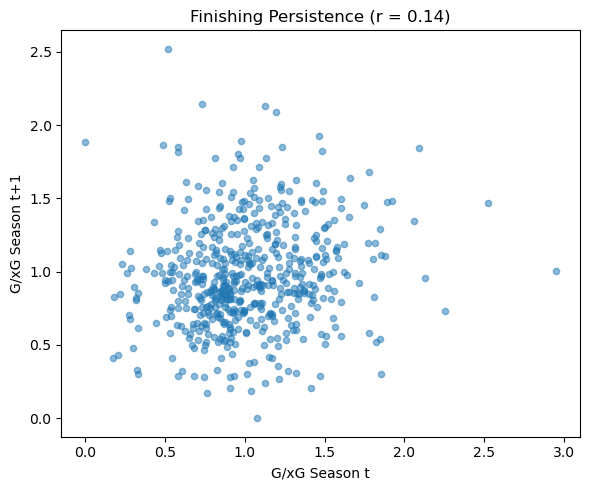

In [4]:
df_persist = df_f.copy().sort_values(["player", "season"])
df_persist["next_g_xg"] = df_persist.groupby("player")["g_per_xg"].shift(-1)
df_persist = df_persist.dropna(subset=["next_g_xg"])

corr = df_persist[["g_per_xg", "next_g_xg"]].corr().iloc[0, 1]
print(f"Year-on-year G/xG correlation: {corr:.2f}")

plt.figure(figsize=(6, 5))
plt.scatter(df_persist["g_per_xg"], df_persist["next_g_xg"], alpha=0.5, s=20)
plt.xlabel("G/xG Season t")
plt.ylabel("G/xG Season t+1")
plt.title(f"Finishing Persistence (r = {corr:.2f})")
plt.tight_layout()
plt.show()

The weak year-on-year correlation (r ≈ 0.14) confirms that finishing performance is heavily influenced by variance and sample size. Short-term overperformance of xG is not a reliable indicator of long-term skill — this motivates a Bayesian shrinkage approach rather than naive G/xG comparisons.

---
## 4. Baseline Model (xG only)

The simplest possible model: predict goals directly from xG, assuming all players finish at an average rate.

In [5]:
# Train: 2014–2022 | Test: 2023
train_final = df_f[df_f["season"] <= 2022].copy()
df_test     = df_f[df_f["season"] == 2023].copy()

mae_xg  = mean_absolute_error(df_test["npg"], df_test["npxg"])
rmse_xg = np.sqrt(mean_squared_error(df_test["npg"], df_test["npxg"]))

print("xG baseline — 2023 out-of-sample")
print(f"  MAE:  {mae_xg:.3f}")
print(f"  RMSE: {rmse_xg:.3f}")

xG baseline — 2023 out-of-sample
  MAE:  1.893
  RMSE: 2.490


---
## 5. Overdispersion Check

Goals are often modelled as Poisson, but Poisson assumes variance = mean. We check whether this holds.

In [6]:
mean_goals = df_f["npg"].mean()
var_goals  = df_f["npg"].var()
dispersion = var_goals / mean_goals

print(f"Mean goals:       {mean_goals:.3f}")
print(f"Variance:         {var_goals:.3f}")
print(f"Dispersion ratio: {dispersion:.3f}  (>1 indicates overdispersion)")

Mean goals:       6.780
Variance:         19.552
Dispersion ratio: 2.884  (>1 indicates overdispersion)


---
## 6. Bayesian Hierarchical Models

### Model Specification

Each player is assigned a latent finishing parameter **α** representing their systematic tendency to over- or under-perform xG. The model is:

$$\log(\mu_i) = \alpha_{\text{player}} + \log(\text{xG}_i)$$

The xG term acts as an exposure offset. Partial pooling shrinks low-sample players toward the league mean, while high-exposure players can deviate more freely.

We fit two versions to compare:
- **Poisson** — standard count model
- **Negative Binomial** — allows additional variance beyond Poisson

Both use a non-centred parameterisation for better MCMC geometry.

In [7]:
# Build player index from training data only
player_to_id_final = {p: i for i, p in enumerate(train_final["player"].unique())}
train_final["player_id"] = train_final["player"].map(player_to_id_final)
df_test["player_id"]     = df_test["player"].map(player_to_id_final)

y_final          = train_final["npg"].values
xg_final         = train_final["npxg"].values
log_xg_final     = np.log(xg_final)
player_idx_final = train_final["player_id"].values
n_players_final  = train_final["player_id"].nunique()

print(f"Training observations: {train_final.shape[0]}")
print(f"Test observations:     {df_test.shape[0]}")
print(f"Training players:      {n_players_final}")
print(f"Unseen test players:   {df_test['player_id'].isna().sum()}")

Training observations: 831
Test observations:     119
Training players:      364
Unseen test players:   40


In [8]:
# ── Poisson hierarchical model ──────────────────────────────────────────────
with pm.Model() as finishing_model:

    # Population-level finishing distribution
    mu_alpha    = pm.Normal("mu_alpha", mu=0.0, sigma=0.5)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=0.5)

    # Non-centred player effects (better MCMC geometry)
    z_alpha = pm.Normal("z_alpha", mu=0.0, sigma=1.0, shape=n_players_final)
    alpha   = pm.Deterministic("alpha", mu_alpha + z_alpha * sigma_alpha)

    # Expected goals with xG exposure offset
    eta = alpha[player_idx_final] + log_xg_final
    mu  = pm.math.exp(eta)

    goals_obs = pm.Poisson("goals_obs", mu=mu, observed=y_final)

    trace = pm.sample(
        draws=2000, tune=2000,
        target_accept=0.9, chains=4,
        random_seed=RANDOM_SEED
    )

az.summary(trace, var_names=["mu_alpha", "sigma_alpha"])

C:\Users\barbara\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 102 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.017,0.015,-0.045,0.011,0.000,0.0,7850.0,5487.0,1.0
sigma_alpha,0.065,0.028,0.007,0.112,0.001,0.0,1354.0,1648.0,1.0


In [9]:
# ── Negative Binomial hierarchical model ────────────────────────────────────
with pm.Model() as negbin_finishing_model:

    mu_alpha    = pm.Normal("mu_alpha", mu=0.0, sigma=0.5)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=0.5)

    z_alpha = pm.Normal("z_alpha", mu=0.0, sigma=1.0, shape=n_players_final)
    alpha   = pm.Deterministic("alpha", mu_alpha + z_alpha * sigma_alpha)

    eta = alpha[player_idx_final] + log_xg_final
    mu  = pm.math.exp(eta)

    # Overdispersion parameter
    phi = pm.HalfNormal("phi", sigma=2)

    goals_obs = pm.NegativeBinomial("goals_obs", mu=mu, alpha=phi, observed=y_final)

    trace_nb = pm.sample(
        draws=2000, tune=2000,
        target_accept=0.9, chains=4,
        random_seed=RANDOM_SEED
    )

az.summary(trace_nb, var_names=["mu_alpha", "sigma_alpha", "phi"])

C:\Users\barbara\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, phi]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 108 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.012,0.017,-0.042,0.020,0.000,0.000,12709.0,5283.0,1.0
sigma_alpha,0.027,0.020,0.000,0.062,0.000,0.000,3308.0,3633.0,1.0
phi,14.804,1.150,12.754,17.038,0.011,0.014,11212.0,5505.0,1.0


---
## 7. Model Evaluation & Comparison

Models are evaluated on the held-out 2023 season using MAE, RMSE, and LOO-CV (ELPD).

In [10]:
# ── Point predictions ────────────────────────────────────────────────────────
alpha_means    = trace.posterior["alpha"].mean(dim=("chain", "draw")).values
alpha_means_nb = trace_nb.posterior["alpha"].mean(dim=("chain", "draw")).values

player_alpha    = {p: alpha_means[i]    for p, i in player_to_id_final.items()}
player_alpha_nb = {p: alpha_means_nb[i] for p, i in player_to_id_final.items()}

df_test["alpha"]         = df_test["player"].map(player_alpha).fillna(0)
df_test["alpha_nb"]      = df_test["player"].map(player_alpha_nb).fillna(0)
df_test["pred_goals"]    = df_test["npxg"] * np.exp(df_test["alpha"])
df_test["pred_goals_nb"] = df_test["npxg"] * np.exp(df_test["alpha_nb"])

mae_model  = mean_absolute_error(df_test["npg"], df_test["pred_goals"])
rmse_model = np.sqrt(mean_squared_error(df_test["npg"], df_test["pred_goals"]))
mae_nb     = mean_absolute_error(df_test["npg"], df_test["pred_goals_nb"])
rmse_nb    = np.sqrt(mean_squared_error(df_test["npg"], df_test["pred_goals_nb"]))

print(f"{'Model':<22} {'MAE':>6} {'RMSE':>7}")
print("-" * 36)
print(f"{'xG baseline':<22} {mae_xg:>6.3f} {rmse_xg:>7.3f}")
print(f"{'Poisson hierarchical':<22} {mae_model:>6.3f} {rmse_model:>7.3f}")
print(f"{'Negative Binomial':<22} {mae_nb:>6.3f} {rmse_nb:>7.3f}")

Model                     MAE    RMSE
------------------------------------
xG baseline             1.893   2.490
Poisson hierarchical    1.839   2.417
Negative Binomial       1.865   2.458


In [11]:
# ── LOO-CV (log predictive density) ─────────────────────────────────────────
with finishing_model:
    trace = pm.compute_log_likelihood(trace)

with negbin_finishing_model:
    trace_nb = pm.compute_log_likelihood(trace_nb)

loo_pois = az.loo(trace)
loo_nb   = az.loo(trace_nb)

az.compare({"Poisson": trace, "NegBin": trace_nb})

Output()

Output()

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Poisson,0,-1845.343754,19.545086,0.000000,1.0,17.575571,0.000000,False,log
NegBin,1,-1896.239136,2.836787,50.895381,0.0,14.829582,4.960034,False,log


In [12]:
# ── Posterior predictive credible intervals (Poisson model) ──────────────────
alpha_samples = trace.posterior["alpha"].stack(sample=("chain", "draw")).values
n_samples     = alpha_samples.shape[1]
player_ids    = df_test["player_id"].values

mu_samples = np.zeros((len(df_test), n_samples))
for i, pid in enumerate(player_ids):
    if np.isnan(pid):
        mu_samples[i] = df_test.iloc[i]["npxg"]  # unseen player → average
    else:
        mu_samples[i] = df_test.iloc[i]["npxg"] * np.exp(alpha_samples[int(pid)])

goal_samples = np.random.poisson(mu_samples)

df_test["pred_mean"]  = goal_samples.mean(axis=1)
df_test["pred_lower"] = np.percentile(goal_samples, 10, axis=1)
df_test["pred_upper"] = np.percentile(goal_samples, 90, axis=1)

coverage_80 = (
    (df_test["npg"] >= df_test["pred_lower"]) &
    (df_test["npg"] <= df_test["pred_upper"])
).mean()
print(f"80% credible interval coverage: {coverage_80:.1%}")

80% credible interval coverage: 92.4%


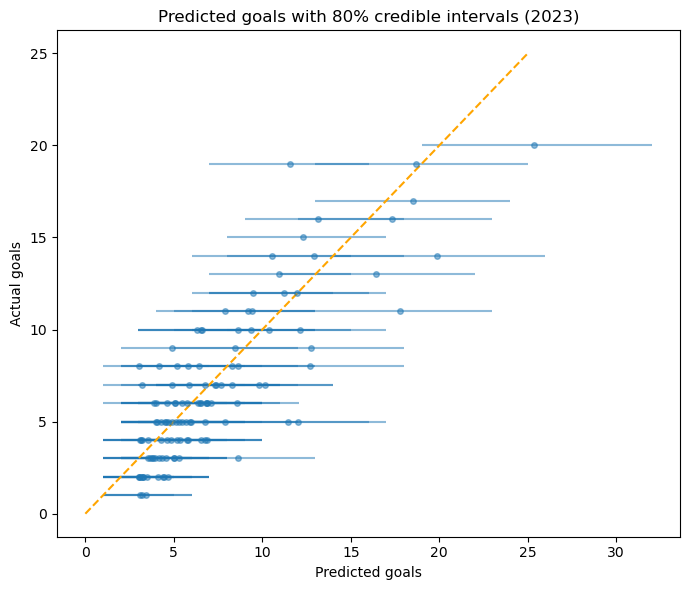

In [13]:
# Plot predicted goals with 80% CIs
plot_df = df_test.sort_values("pred_mean")

plt.figure(figsize=(7, 6))
plt.errorbar(
    plot_df["pred_mean"], plot_df["npg"],
    xerr=[plot_df["pred_mean"] - plot_df["pred_lower"],
          plot_df["pred_upper"] - plot_df["pred_mean"]],
    fmt="o", alpha=0.5, markersize=4
)
plt.plot([0, 25], [0, 25], "--", color="orange")
plt.xlabel("Predicted goals")
plt.ylabel("Actual goals")
plt.title("Predicted goals with 80% credible intervals (2023)")
plt.tight_layout()
plt.show()

---
## 8. Results: Player Finishing Ability

We extract the posterior α for each player from the winning Poisson model. α > 0 means above-average finishing; α < 0 means underperformance relative to xG.

We apply a minimum cumulative xG threshold (≥10 over the training period) to exclude very low-exposure players whose estimates are highly uncertain.

In [14]:
# Posterior summaries for all training players
alpha_post  = trace.posterior["alpha"].stack(sample=("chain", "draw")).values
alpha_mean  = alpha_post.mean(axis=1)
alpha_lower = np.percentile(alpha_post, 10, axis=1)
alpha_upper = np.percentile(alpha_post, 90, axis=1)

alpha_summary = pd.DataFrame({
    "player":    list(player_to_id_final.keys()),
    "player_id": list(player_to_id_final.values())
}).sort_values("player_id").reset_index(drop=True)

alpha_summary["alpha_mean"]          = alpha_mean
alpha_summary["alpha_lower"]         = alpha_lower
alpha_summary["alpha_upper"]         = alpha_upper
alpha_summary["finishing_multiplier"] = np.exp(alpha_summary["alpha_mean"])
alpha_summary["ci_width"]            = alpha_upper - alpha_lower

# Merge training totals
player_train_totals = train_final.groupby("player", as_index=False)[
    ["npg", "npxg", "minutes", "shots"]
].sum()
alpha_summary = alpha_summary.merge(player_train_totals, on="player", how="left")

# Apply minimum exposure filter
alpha_summary_filtered = alpha_summary[alpha_summary["npxg"] >= 10].copy()
print(f"Players after xG filter: {len(alpha_summary_filtered)}")

Players after xG filter: 154


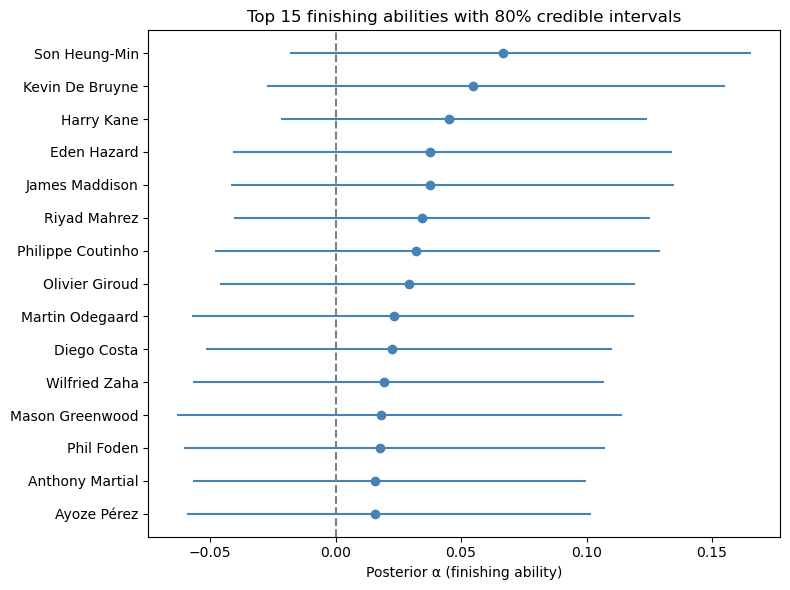

In [15]:
# Top 15 finishers
top15 = alpha_summary_filtered.sort_values("alpha_mean", ascending=False).head(15).sort_values("alpha_mean")

plt.figure(figsize=(8, 6))
plt.errorbar(
    top15["alpha_mean"], top15["player"],
    xerr=[top15["alpha_mean"] - top15["alpha_lower"],
          top15["alpha_upper"] - top15["alpha_mean"]],
    fmt="o", color="steelblue"
)
plt.axvline(0, linestyle="--", color="grey")
plt.xlabel("Posterior α (finishing ability)")
plt.title("Top 15 finishing abilities with 80% credible intervals")
plt.tight_layout()
plt.show()

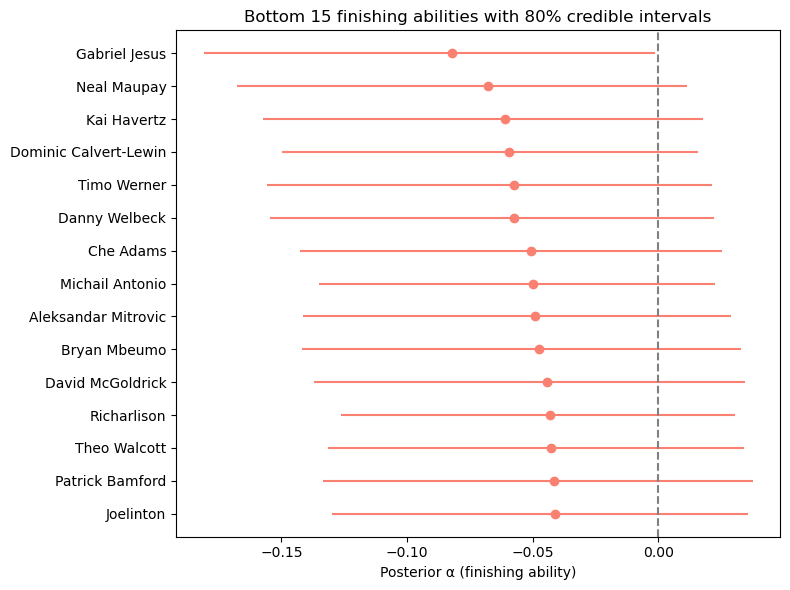

In [16]:
# Bottom 15 finishers
bot15 = alpha_summary_filtered.sort_values("alpha_mean", ascending=True).head(15).sort_values("alpha_mean", ascending=False)

plt.figure(figsize=(8, 6))
plt.errorbar(
    bot15["alpha_mean"], bot15["player"],
    xerr=[bot15["alpha_mean"] - bot15["alpha_lower"],
          bot15["alpha_upper"] - bot15["alpha_mean"]],
    fmt="o", color="salmon"
)
plt.axvline(0, linestyle="--", color="grey")
plt.xlabel("Posterior α (finishing ability)")
plt.title("Bottom 15 finishing abilities with 80% credible intervals")
plt.tight_layout()
plt.show()

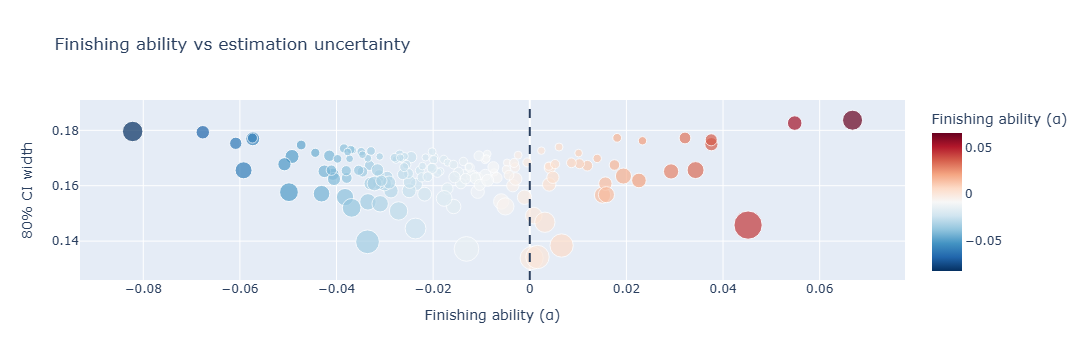

In [17]:
# Finishing ability vs estimation uncertainty — interactive
fig = px.scatter(
    alpha_summary_filtered,
    x="alpha_mean",
    y="ci_width",
    size="npxg",
    color="alpha_mean",
    hover_name="player",
    color_continuous_scale="RdBu_r",
    title="Finishing ability vs estimation uncertainty",
    labels={
        "alpha_mean": "Finishing ability (α)",
        "ci_width":   "80% CI width",
        "npxg":       "Total xG (training)"
    }
)
fig.add_vline(x=0, line_dash="dash")
fig.show()

In [18]:
# Players whose 80% CI is entirely above zero — statistically above-average finishers
sig_finishers = alpha_summary_filtered[alpha_summary_filtered["alpha_lower"] > 0].sort_values("alpha_mean", ascending=False)
print(f"Players with α credibly > 0 (80% CI): {len(sig_finishers)}")
sig_finishers[["player", "alpha_mean", "alpha_lower", "alpha_upper", "finishing_multiplier", "npxg"]]

Players with α credibly > 0 (80% CI): 0


,player,alpha_mean,alpha_lower,alpha_upper,finishing_multiplier,npxg


---
## 9. Player Profiling

Using the available data we can combine shot volume, shot quality, and finishing ability into a two-dimensional shooting profile. This can help distinguish players who score through volume vs. chance selection vs. finishing skill.

In [19]:
player_profile = train_final.groupby("player").agg(
    minutes=("minutes", "sum"),
    shots=("shots", "sum"),
    npg=("npg", "sum"),
    npxg=("npxg", "sum")
).reset_index()

player_profile["shots_per90"] = player_profile["shots"] / player_profile["minutes"] * 90
player_profile["xg_per90"]    = player_profile["npxg"]  / player_profile["minutes"] * 90
player_profile["xg_per_shot"] = player_profile["npxg"]  / player_profile["shots"]

player_profile = player_profile.merge(
    alpha_summary_filtered[["player", "alpha_mean"]],
    on="player", how="inner"  # inner join: only profiled players with reliable alpha
)

print(f"Players in profile: {len(player_profile)}")

Players in profile: 154


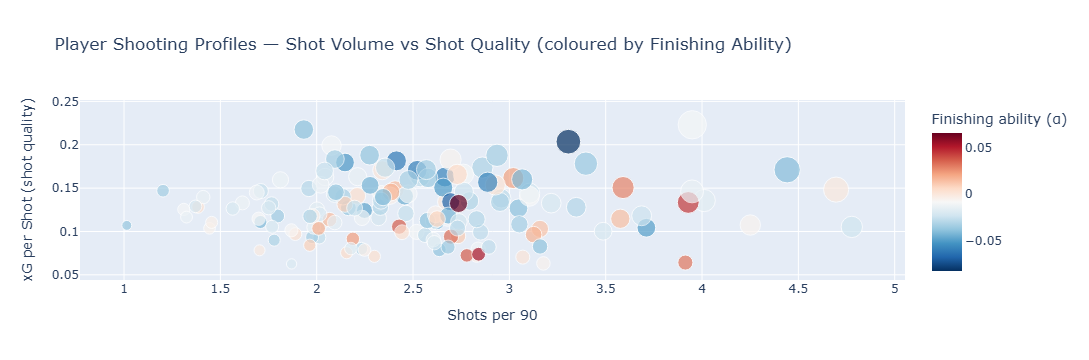

In [20]:
fig = px.scatter(
    player_profile,
    x="shots_per90",
    y="xg_per_shot",
    color="alpha_mean",
    hover_name="player",
    size="xg_per90",
    color_continuous_scale="RdBu_r",
    title="Player Shooting Profiles — Shot Volume vs Shot Quality (coloured by Finishing Ability)",
    labels={
        "shots_per90": "Shots per 90",
        "xg_per_shot": "xG per Shot (shot quality)",
        "alpha_mean":  "Finishing ability (α)"
    }
)
fig.show()